<a href="https://colab.research.google.com/github/Marccrampe/Custom_LULC_Data_Fusion/blob/main/Data_Fusion_for_Urban_Monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Earth's Pulse, City's Breath: Enhancing Urban Land Cover Classification through SAR and Sentinel-2 Data Fusion**

Authors :

**Marc Crampe, Emilio Picard**
: *EuroMoonMars, Terraprisma, IPSA, ENS-Paris-Saclay*

**Abstract**:

Urban areas face unique challenges in monitoring and managing land cover changes, particularly due to cloud cover that affects optical imagery. This project presents an innovative approach to urban land cover classification by fusing Sentinel-1 Synthetic Aperture Radar (SAR) data with Sentinel-2 optical data.

The objective is to develop an automated algorithm capable of monthly monitoring of urban land cover changes. By enhancing classification accuracy, the project aims to provide critical insights into urban growth and environmental resilience.

A merged dataset of 20 bands was created using:

- Sentinel-1: VV, VH, VV/VH (from 4 images).
- Sentinel-2: Spectral indices (NDVI, SAVI, BAI, NDWI) and original bands (B2, B3, B4, B8).
- Several machine learning models (SVM, KNN, RF, NN) and advanced methods (CNN, SAM2) were evaluated to classify urban features accurately.



***Results demonstrate the potential of SAR and optical data fusion to overcome the limitations of cloud cover, providing a robust framework for urban land cover monitoring.***


The entire training dataset and relevant parts of my research are available on GitHub, allowing for easy access and reproducibility. I have used various Python libraries, such as geemap for visualization, scikit-learn for machine learning models, and tensorflow for neural network approaches. These tools work in tandem with GEE, providing powerful capabilities to process large geospatial datasets efficiently.

Although the project is a work in progress and I have not yet fully automated the process, I am committed to completing the automation of the code as soon as possible. This will allow for real-time urban land cover monitoring using the fused Sentinel-1 and Sentinel-2 data.


## 1.Introduction :
With nearly 90% of the world's mapping data generated in recent years, leveraging advanced technologies for accurate mapping is crucial. Rapid urbanization demands precise tools to monitor land cover changes, which can help identify environmental impacts and guide sustainable urban development.

However, optical imagery, like that from Sentinel-2, is often hindered by cloud cover, especially in tropical and coastal areas, resulting in data gaps. For example, in Rouen, France, persistent clouds limit usable optical images to only ten per year, complicating urban monitoring.

This study addresses this challenge by combining Sentinel-1 Synthetic Aperture Radar (SAR) and Sentinel-2 data through fusion techniques, reducing the impact of cloud cover. The goal is to evaluate and compare machine learning models, such as Random Forest, SVM, and CNNs, to identify the most effective approaches for accurate urban land cover classification.



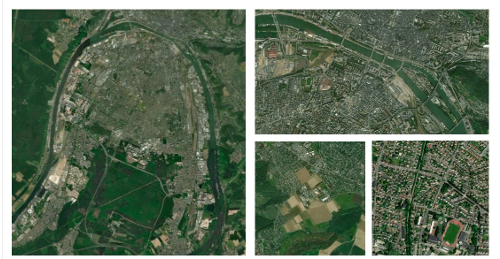

# 2. Data Preparation and Preprocessing



In [22]:
# Importing the Earth Engine library and authenticating the session
import ee
ee.Authenticate()
ee.Initialize(project='ee-user')

In [2]:
#Mount your drive to acess the training data set
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 67.9 MB/s eta 0:00:00


Define your Aera of Interest (AoI) : In this case study -> AoI : Rouen, France

In [4]:
geojson ={
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              0.9784323991431165,
              49.461026992782706
            ],
            [
              0.9784323991431165,
              49.32695727682673
            ],
            [
              1.1641955471756376,
              49.32695727682673
            ],
            [
              1.1641955471756376,
              49.461026992782706
            ],
            [
              0.9784323991431165,
              49.461026992782706
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}

polygon = ee.Geometry.Polygon(geojson['features'][0]['geometry']['coordinates'])


# Preprocessing Sentinel-1 and Sentinel-2 Data

**1. Sentinel-1 Preprocessing**


First, we load the Sentinel-1 data, which includes SAR (Synthetic Aperture Radar) data in two key bands: VV (Vertical-Vertical polarization) and VH (Vertical-Horizontal polarization). We then apply necessary filtering based on the area of interest (AoI) and time range. Additionally, we calculate the ratio of the VV to VH bands (VV/VH), which can provide useful information about the land surface, especially in urban environments.



In [6]:
# Charger la collection Sentinel-1

s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(polygon) \
    .filterDate('2023-01-01', '2023-12-31') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
    .select(['VV', 'VH'])

# Convertir en dB
def to_db(image):
    return image.log10().multiply(10).copyProperties(image, ["system:time_start"])

s1_db = s1_collection

# Calculer la moyenne
s1_mean = s1_db.mean().clip(polygon)

# Calculer le ratio VH/VV
ratio = s1_mean.expression(
    'VH - VV', {
        'VH': s1_mean.select('VH'),
        'VV': s1_mean.select('VV')
    }).rename('VH_VV')

# Ajouter le ratio aux bandes
s1_image = s1_mean.addBands(ratio)


**2. Sentinel-2 Preprocessing**


Next, we retrieve the Sentinel-2 optical imagery. We filter the data to our AoI and the desired time range. Additionally, we can apply cloud masking to exclude cloudy images from the dataset, as clouds can interfere with the classification. After retrieving the images, we calculate various spectral indices such as NDVI (Normalized Difference Vegetation Index), NDWI (Normalized Difference Water Index), SAVI (Soil Adjusted Vegetation Index), and BAI (Burn Area Index), which are critical for distinguishing different land cover types, particularly vegetation, water, and urban areas.

In [7]:
# Fonction de masquage des nuages
def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
             .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).copyProperties(image, ["system:time_start"])

# Charger la collection Sentinel-2
s2_collection = ee.ImageCollection('COPERNICUS/S2_SR') \
    .filterBounds(polygon) \
    .filterDate('2023-01-01', '2023-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(maskS2clouds)

# Sélectionner les bandes nécessaires
s2_bands = ['B2', 'B3', 'B4', 'B8']
s2 = s2_collection.select(s2_bands)

# Calculer les indices
def addIndices(image):
    # NDVI
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    # SAVI
    savi = image.expression(
        '1.5 * (NIR - RED) / (NIR + RED + 0.5)', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('SAVI')
    # BAI
    bai = image.expression(
        '(BLUE - NIR) / (BLUE + NIR)', {
            'BLUE': image.select('B2'),
            'NIR': image.select('B8')
        }).rename('BAI')
    # NDWI
    ndwi = image.normalizedDifference(['B8', 'B4']).rename('NDWI')
    # Ajouter les indices
    return image.addBands([ndvi, savi, bai, ndwi])

s2_indices = s2.map(addIndices)

# Calculer la médiane
s2_image = s2_indices.median().clip(polygon)


In [8]:
import geemap

def plot_indices_and_rgb(s1_image, s2_image, geometry):
    """
    Fonction pour afficher les indices Sentinel-2 et les images Sentinel-1 et Sentinel-2 en RGB.

    Paramètres :
    - s1_image : Image Sentinel-1 prétraitée
    - s2_image : Image Sentinel-2 prétraitée avec bandes et indices
    - geometry : Zone d'intérêt à afficher
    """
    # Créer une carte interactive
    Map = geemap.Map()

    # Centrer la carte sur le polygone (geometry) avec un facteur de zoom automatique
    Map.centerObject(geometry, zoom=10)

    # Afficher l'image Sentinel-1 en VV et VH
    s1_vv_vh_viz = {
        'min': -20,
        'max': 0,
        'bands': ['VV', 'VH', 'VH_VV']  # Aucune palette ici, juste les bandes en RGB
    }
    Map.addLayer(s1_image.clip(geometry), s1_vv_vh_viz, 'Sentinel-1 (VV, VH, VH/VV)')

    # Afficher l'image Sentinel-2 en RGB
    s2_rgb_viz = {
        'min': 0,
        'max': 3000,
        'bands': ['B4', 'B3', 'B2']  # Rouge, Vert, Bleu
    }
    Map.addLayer(s2_image.clip(geometry), s2_rgb_viz, 'Sentinel-2 (RGB)')

    # Afficher l'indice NDVI
    ndvi_viz = {
        'min': 0,
        'max': 0.5,
        'palette': ['blue', 'cyan', 'red']
    }
    Map.addLayer(s2_image.select('NDVI').clip(geometry), ndvi_viz, 'NDVI')

    # Afficher l'indice SAVI
    savi_viz = {
        'min': 0,
        'max': 1,
        'palette': ['red', 'yellow', 'green']
    }
    Map.addLayer(s2_image.select('SAVI').clip(geometry), savi_viz, 'SAVI')

    # Afficher l'indice BAI
    bai_viz = {
        'min': -0.5,
        'max': 0.5,
        'palette': ['white', 'orange', 'red']
    }
    Map.addLayer(s2_image.select('BAI').clip(geometry), bai_viz, 'BAI')

    # Afficher l'indice NDWI
    ndwi_viz = {
        'min': 0,
        'max': 0.5,
        'palette': ['blue', 'yellow','red']
    }
    Map.addLayer(s2_image.select('NDWI').clip(geometry), ndwi_viz, 'NDWI')

    # Afficher la carte
    Map.addLayerControl()  # Ajouter un contrôle pour les couches
    return Map


In [9]:
plot_indices_and_rgb(s1_image, s2_image, polygon)


Map(center=[49.393998839918474, 1.071313973159288], controls=(WidgetControl(options=['position', 'transparent_…

- **NDVI** (Normalized Difference Vegetation Index): Highlights vegetation health.
- **SAVI**(Soil Adjusted Vegetation Index): Adjusts for soil influence in areas with sparse vegetation.
- **BAI** (Burned Area Index): Detects bare soil and sparse vegetation.
- **NDWI** (Normalized Difference Water Index): Identifies water bodies and moisture.

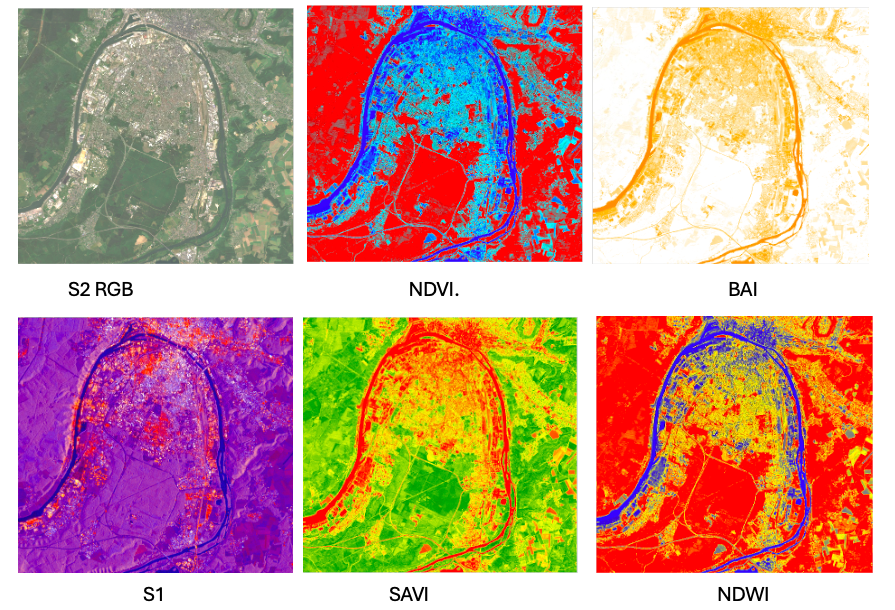

Retrieve in batches of 4 to ensure sufficient data, with 4 Sentinel-1 acquisitions, each including 3 polarizations.

S1 = 4x3 bands

In [10]:
# Charger la collection Sentinel-1
s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(polygon) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
    .select(['VV', 'VH'])

# Fonction pour récupérer un batch de 4 images pour une année
def get_s1_images(year):
    periods = [
        ('{}-01-01'.format(year), '{}-03-31'.format(year)),
        ('{}-04-01'.format(year), '{}-06-30'.format(year)),
        ('{}-07-01'.format(year), '{}-09-30'.format(year)),
        ('{}-10-01'.format(year), '{}-12-31'.format(year))
    ]

    images = []
    for start_date, end_date in periods:
        s1_period = s1_collection.filterDate(start_date, end_date)
        s1_mean = s1_period.mean().clip(polygon)
        ratio = s1_mean.expression(
            'VH - VV', {
                'VH': s1_mean.select('VH'),
                'VV': s1_mean.select('VV')
            }).rename('VH_VV')
        s1_image = s1_mean.addBands(ratio)
        images.append(s1_image)

    return images

# Fusionner (merge) les 4 images Sentinel-1 en une seule
def merge_s1_images(s1_images):
    merged_s1 = s1_images[0]
    for img in s1_images[1:]:
        merged_s1 = merged_s1.addBands(img)
    return merged_s1

# Récupérer 4 images pour l'année 2023
s1_images = get_s1_images(2023)

# Fusionner les 4 images Sentinel-1 en une seule
merged_s1_image = merge_s1_images(s1_images)


##### SENTINEL 2 GET DATA : B2, B3, B4, B8 , NDVI, NDWI, SAVI, BAI
merged_image = merged_s1_image.addBands(s2_image)

The final merged image consists of 20 bands:
- **Sentinel-1**: 4 images × 3 bands (VV, VH, VV/VH).
- **Sentinel-2**: The 5 special indices plus the original B2, B3, B4, B8 bands.
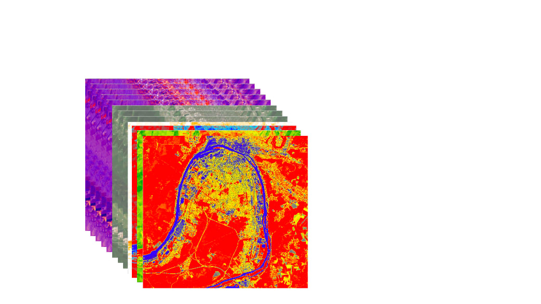

In [23]:
# Obtenir les informations de l'image fusionnée
info = merged_image.getInfo()

# Récupérer les bandes de l'image
bands = info['bands']

# Afficher le nombre de bandes (layers)
print("Number of bands:", len(bands))

# Facultatif : Afficher les noms des bandes
band_names = [band['id'] for band in bands]
print("Name of bands:", band_names)


Number of bands: 20
Name of bands: ['VV', 'VH', 'VH_VV', 'VV_1', 'VH_1', 'VH_VV_1', 'VV_2', 'VH_2', 'VH_VV_2', 'VV_3', 'VH_3', 'VH_VV_3', 'B2', 'B3', 'B4', 'B8', 'NDVI', 'SAVI', 'BAI', 'NDWI']


Now that we have preprocessed the data, we can create our training set and perform classification using different models, including machine learning algorithms and convolutional neural networks (CNNs).


# 3.Creating the Training Dataset

***NB: if you want to run the case study , you can skip this step as the training saved is already on the GitHub***


To create the training dataset, we use the geemap library, which simplifies the process by allowing us to manually define features directly on the map. Here's how it works:

**Interactive Mapping:**

 We use geemap to create an interactive map where we can easily visualize the Sentinel-2 and Sentinel-1 data. The Sentinel-2 image is displayed in RGB format using the red (B4), green (B3), and blue (B2) bands, and we also display the processed Sentinel-1 data for context.

**Drawing Features:**

In geemap, we can enable the drawing control on the map. This allows us to manually draw polygons or points that represent the different land cover classes, such as vegetation, water, urban areas, forest, and crops. Each drawn feature is assigned a class label (e.g., 0 for vegetation, 1 for water, etc.).

**Creating the Training Samples:**

 Once we draw the polygons on the map, we retrieve them as a FeatureCollection. For each polygon (representing a land cover class), we manually assign a class label. These labeled polygons are then merged into a single FeatureCollection, which forms the complete training dataset.

**Exporting the Training Samples:**

 The final training set is exported to Google Drive as a GeoJSON file (or another format like SHP or KML). This dataset can then be used for training machine learning models like Random Forest, Support Vector Machines, or Convolutional Neural Networks.

*This method makes it easy to quickly create labeled training samples by visually selecting features on the map, which is especially useful when preparing training data for machine learning classification tasks.*



In [24]:
import geemap

"""
Function to display Sentinel-2 indices and Sentinel-1 and Sentinel-2 images in RGB.

Parameters:
- s1_image: Preprocessed Sentinel-1 image
- s2_image: Preprocessed Sentinel-2 image with bands and indices
- geometry: Area of interest to display
"""

# Create an interactive map
Map = geemap.Map()

# Center the map on the polygon (geometry) with an automatic zoom level
Map.centerObject(polygon, zoom=10)

# Display the Sentinel-2 image in RGB
s2_rgb_viz = {
    'min': 0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2']  # Red, Green, Blue
}
Map.addLayer(s2_image.clip(polygon), s2_rgb_viz, 'Sentinel-2 (RGB)')

# Display the map
Map.addLayerControl()  # Add a layer control to toggle layers

# Enable drawing mode to add samples directly on the map
Map.add_draw_control()

# Display the map
Map
# Once the polygons are drawn, you can retrieve them as FeatureCollections
# For example, suppose you draw polygons for vegetation and water


Map(center=[49.393998839918474, 1.071313973159288], controls=(WidgetControl(options=['position', 'transparent_…

***NB : Only if you don’t have a training set, draw the polygons corresponding to your classes in the correct order.***

In [14]:
# Récupérer les géométries (polygones dessinés)
drawn_features = Map.draw_features

# Créer des labels manuellement (par exemple, 0 pour la végétation, 1 pour l'eau)
vegetation = ee.FeatureCollection(drawn_features[0]).map(lambda f: f.set('class', 0))  # Classe 0 : Végétation
water = ee.FeatureCollection(drawn_features[1]).map(lambda f: f.set('class', 1))  # Classe 1 : Eau
urban_areas = ee.FeatureCollection(drawn_features[2]).map(lambda f: f.set('class', 2))  # Classe 2 : Urbain
forest = ee.FeatureCollection(drawn_features[3]).map(lambda f: f.set('class', 3))  # Classe 3 : Foret
crops = ee.FeatureCollection(drawn_features[4]).map(lambda f: f.set('class', 4))  # Classe 4 : Agriculture


IndexError: list index out of range

Merge all the training samples into one collection

In [16]:
# Fusionner toutes les classes en une seule FeatureCollection
training_samples = vegetation.merge(water).merge(urban_areas).merge(forest).merge(crops)

# Afficher le nombre d'échantillons pour vérifier
print(f"Nombre total d'échantillons : {training_samples.size().getInfo()}")



# Créer une tâche d'exportation pour Google Drive
task = ee.batch.Export.table.toDrive(
    collection=training_samples,
    description='export_training_samples',
    fileNamePrefix='training_samples',
    fileFormat='GeoJSON',  # Vous pouvez aussi utiliser 'SHP', 'KML', etc.
    folder='/content/drive/My Drive/Data_Fusion_Traing_Set'  # Spécifiez le dossier dans Google Drive
)
task.start()

print("Tâche d'exportation lancée. Vérifiez Google Drive pour le fichier.")

NameError: name 'vegetation' is not defined

# 4. Load the Training Set and Test the ML Models

In this step, we load the training dataset, either pre-constructed or exported earlier, to evaluate the performance of various Machine Learning (ML) models for land cover classification.

The process involves:

- Loading the training set into the environment.
- Applying ML models such as Random Forest (RF), Support Vector Machines (SVM), K-Nearest Neighbors (KNN), and Decision Trees (DT).
- Evaluating the models using performance metrics like accuracy, precision, and recall.

This comprehensive testing ensures that the models are robust and capable of accurately classifying land cover features in the specified area.








**RANDOM FOREST Testing**

In [25]:
import json

# Spécifiez le chemin du fichier dans Google Drive
file_path = '/content/drive/MyDrive/Data_Fusion_Traing_Set/Training_Sample_Best.geojson'  # Remplacez ce chemin par le chemin correct

# Lire le fichier GeoJSON
with open(file_path) as f:
    geojson = json.load(f)

# Charger le GeoJSON en tant que FeatureCollection
training_samples_drive = ee.FeatureCollection(geojson)

# Assurer que 'merged_image' est bien défini, sinon, remplace-le par ton image fusionnée
# merged_image = s1_image.addBands(s2_image)

# Ajouter les échantillons à l'image fusionnée pour obtenir les valeurs des bandes
training = merged_image.sampleRegions(
    collection=training_samples_drive,
    properties=['class'],  # La propriété "class" contient les labels
    scale=10  # Résolution (10m pour Sentinel-2, ajuste selon la résolution de ton image fusionnée)
)

# Créer et entraîner le classificateur Random Forest
classifier_rf = ee.Classifier.smileRandomForest(100).train(
    features=training,
    classProperty='class',
    inputProperties=merged_image.bandNames()
)

# Appliquer le classificateur à l'image fusionnée
classified_image_rf = merged_image.classify(classifier_rf)

Map = geemap.Map()
Map.centerObject(polygon, zoom=10)
# Ajouter l'image classifiée à la carte avec une palette adaptée pour plus de classes
palette = ['green', 'blue', 'red', '#004d00', 'yellow']    # Ajuster en fonction des classes
Map.addLayer(classified_image_rf, {'min': 0, 'max': 4, 'palette': palette}, 'Classified Image')

# Afficher la carte
Map

Map(center=[49.393998839918474, 1.071313973159288], controls=(WidgetControl(options=['position', 'transparent_…

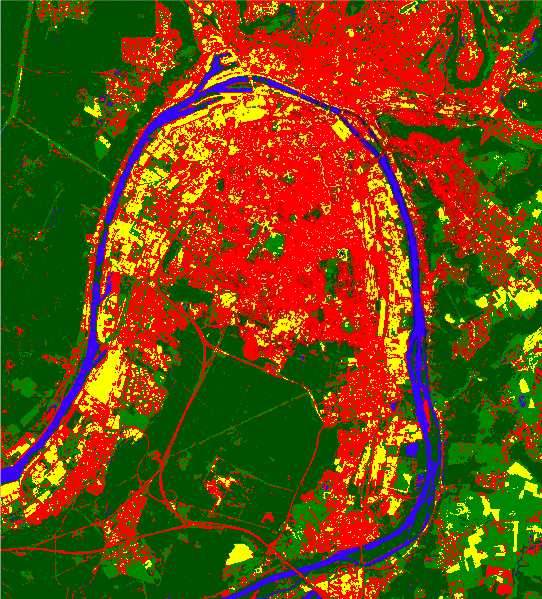

**Test and comparison of different ML models ( RF, DT, SVM , KNN)**

In [17]:
# Ajouter les échantillons à l'image fusionnée pour obtenir les valeurs des bandes
training = merged_image.sampleRegions(
    collection=training_samples_drive,
    properties=['class'],  # La propriété "class" contient les labels
    scale=10  # Résolution (10m pour Sentinel-2, ajuste selon la résolution de ton image fusionnée)
)

# Fonction pour entraîner et classifier avec un modèle donné
def train_and_classify(model, model_name, training_data, merged_image, min_val, max_val, palette):
    classifier = model.train(
        features=training_data,
        classProperty='class',
        inputProperties=merged_image.bandNames()
    )

    classified_image = merged_image.classify(classifier)

    # Ajouter l'image classifiée à la carte avec une palette adaptée pour les classes
    Map.addLayer(classified_image, {'min': min_val, 'max': max_val, 'palette': palette}, f'{model_name} Classified Image')

    return classifier

# Palettes et paramètres communs pour toutes les classes
palette = ['green', 'blue', 'red', '#004d00', 'yellow']  # Ajuster en fonction des classes
min_val, max_val = 0, 4  # Limites des classes

# Entraînement des différents modèles

# 1. Random Forest
classifier_rf = train_and_classify(ee.Classifier.smileRandomForest(100), 'Random Forest', training, merged_image, min_val, max_val, palette)

# 2. KNN
knn_classifier = train_and_classify(ee.Classifier.minimumDistance(), 'KNN', training, merged_image, min_val, max_val, palette)

# 3. SVM (Support Vector Machine)
svm_classifier = train_and_classify(ee.Classifier.libsvm(), 'SVM', training, merged_image, min_val, max_val, palette)

# 4. Decision Tree
decision_tree_classifier = train_and_classify(ee.Classifier.smileCart(), 'Decision Tree', training, merged_image, min_val, max_val, palette)

# Afficher la carte finale
Map


Map(bottom=179458.0, center=[49.40114368635629, 1.1185455322265627], controls=(WidgetControl(options=['positio…

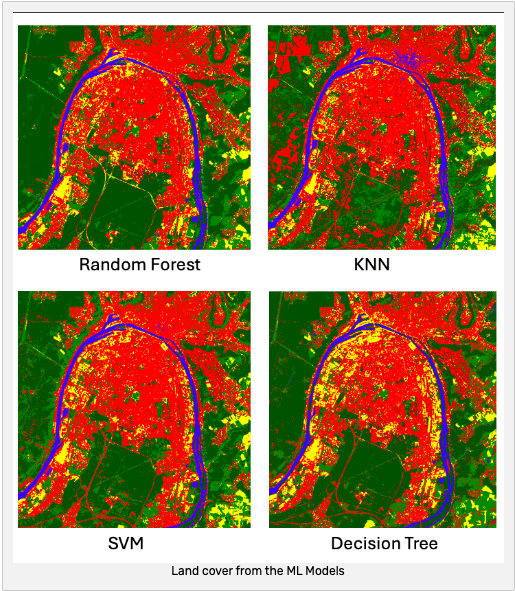

# 5. Validation of ML Models

To validate the performance of the machine learning models, we follow a similar approach to creating the training set. Using an interactive map, you can manually set validation points with their true labels. These points will serve as a reference to assess the accuracy of the model.


The validation process includes generating the confusion matrix for each ML model, which provides insights into the performance of the classification by showing the accuracy per class. This allows us to evaluate how well the model distinguishes between different land cover types and identify any misclassifications.


By comparing the overall accuracy and per-class metrics, we can ensure the robustness of the chosen classifier for the given study area.

***You can start 2 cells later, if you are using the validation dataset from the GitHub file***

In [ ]:
import geemap

"""
Fonction pour afficher les indices Sentinel-2 et les images Sentinel-1 et Sentinel-2 en RGB.

Paramètres :
- s1_image : Image Sentinel-1 prétraitée
- s2_image : Image Sentinel-2 prétraitée avec bandes et indices
- geometry : Zone d'intérêt à afficher
"""
# Créer une carte interactive
Map = geemap.Map()

# Centrer la carte sur le polygone (geometry) avec un facteur de zoom automatique
Map.centerObject(polygon, zoom=10)

# Afficher l'image Sentinel-2 en RGB
s2_rgb_viz = {
    'min': 0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2']  # Rouge, Vert, Bleu
}
Map.addLayer(s2_image.clip(polygon), s2_rgb_viz, 'Sentinel-2 (RGB)')

# Afficher la carte
Map.addLayerControl()  # Ajouter un contrôle pour les couches

# Activer le mode dessin pour ajouter des échantillons directement sur la carte
Map.add_draw_control()

# Afficher la carte
Map


Map(center=[49.393998839918474, 1.071313973159288], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# Créer un ensemble de validation (en supposant que tu aies déjà dessiné des polygones pour la validation)
# Assure-toi d'avoir dessiné des polygones de validation et récupère-les comme une FeatureCollection
validation_features = Map.draw_features  # Remplace ceci par ta propre méthode pour récupérer les polygones de validation

# Assigner des labels aux polygones de validation
vegetation_val = ee.FeatureCollection(validation_features[0]).map(lambda f: f.set('class', 0))  # Classe 0 : Végétation
water_val = ee.FeatureCollection(validation_features[1]).map(lambda f: f.set('class', 1))  # Classe 1 : Eau
urban_areas_val = ee.FeatureCollection(validation_features[2]).map(lambda f: f.set('class', 2))  # Classe 2 : Urbain
forest_val = ee.FeatureCollection(validation_features[3]).map(lambda f: f.set('class', 3))  # Classe 3 : Forêt
crops_val = ee.FeatureCollection(validation_features[4]).map(lambda f: f.set('class', 4))  # Classe 4 : Agriculture

# Fusionner toutes les classes de validation en une seule FeatureCollection
validation_samples = vegetation_val.merge(water_val).merge(urban_areas_val).merge(forest_val).merge(crops_val)


# Créer une tâche d'exportation pour Google Drive
task = ee.batch.Export.table.toDrive(
    collection=validation_samples,
    description='export_validation_samples',
    fileNamePrefix='Validation_Sample_Best',
    fileFormat='GeoJSON',  # Vous pouvez aussi utiliser 'SHP', 'KML', etc.
    folder='Data_Fusion_Traing_Set'  # Spécifiez le dossier dans Google Drive
)

task.start()

print("Tâche d'exportation lancée. Vérifiez Google Drive pour le fichier.")


Tâche d'exportation lancée. Vérifiez Google Drive pour le fichier.


In [ ]:

# Échantillonner les valeurs des bandes pour l'ensemble de validation
validation = merged_image.sampleRegions(
    collection=validation_samples,
    properties=['class'],  # La propriété "class" contient les labels
    scale=10  # Résolution (10m pour Sentinel-2, ajuste selon la résolution de ton image fusionnée)
)


# Fonction pour valider un classificateur, calculer la matrice de confusion et l'exactitude
def validate_classifier(classifier, classifier_name, validation_data):
    # Prédictions sur l'ensemble de validation
    validated = validation_data.classify(classifier)

    # Calculer la matrice de confusion
    confusion_matrix = validated.errorMatrix('class', 'classification')

    # Calculer l'exactitude globale
    accuracy = confusion_matrix.accuracy()

    # Afficher la matrice de confusion et l'exactitude
    print(f'{classifier_name} - Confusion Matrix:', confusion_matrix.getInfo())
    print(f'{classifier_name} - Accuracy:', accuracy.getInfo())

# Validation des différents modèles

# 1. Random Forest
validate_classifier(classifier_rf, 'Random Forest', validation)

# 2. KNN
validate_classifier(knn_classifier, 'KNN', validation)

# 3. SVM (Support Vector Machine)
validate_classifier(svm_classifier, 'SVM', validation)

# 4. Decision Tree
validate_classifier(decision_tree_classifier, 'Decision Tree', validation)

# Afficher la carte finale
Map

Random Forest - Confusion Matrix: [[1399, 0, 0, 1, 0], [0, 2107, 0, 0, 0], [3, 0, 604, 0, 8], [0, 0, 0, 2286, 0], [3, 0, 0, 0, 1668]]
Random Forest - Accuracy: 0.9981433345711103
KNN - Confusion Matrix: [[1397, 0, 0, 3, 0], [0, 2107, 0, 0, 0], [0, 1, 575, 8, 31], [723, 0, 16, 1547, 0], [0, 0, 0, 0, 1671]]
KNN - Accuracy: 0.9032058423072162
SVM - Confusion Matrix: [[433, 0, 0, 967, 0], [0, 2107, 0, 0, 0], [2, 0, 580, 0, 33], [39, 0, 0, 2247, 0], [2, 0, 0, 0, 1669]]
SVM - Accuracy: 0.8708998638445352
Decision Tree - Confusion Matrix: [[954, 36, 36, 374, 0], [0, 2035, 1, 71, 0], [10, 0, 528, 0, 77], [1, 2, 1, 2282, 0], [23, 0, 2, 0, 1646]]
Decision Tree - Accuracy: 0.9215249412055948


Map(bottom=1433625.0, center=[49.39773640716187, 1.1665248870849612], controls=(WidgetControl(options=['positi…

Random Forest - Confusion Matrix:
 [[1399    0    0    1    0]
 [   0 2107    0    0    0]
 [   3    0  604    0    8]
 [   0    0    0 2286    0]
 [   3    0    0    0 1668]]
Random Forest - Accuracy: 0.9981433345711103
KNN - Confusion Matrix:
 [[1397    0    0    3    0]
 [   0 2107    0    0    0]
 [   0    1  575    8   31]
 [ 723    0   16 1547    0]
 [   0    0    0    0 1671]]
KNN - Accuracy: 0.9032058423072162
SVM - Confusion Matrix:
 [[ 433    0    0  967    0]
 [   0 2107    0    0    0]
 [   2    0  580    0   33]
 [  39    0    0 2247    0]
 [   2    0    0    0 1669]]
SVM - Accuracy: 0.8708998638445352
Decision Tree - Confusion Matrix:
 [[ 954   36   36  374    0]
 [   0 2035    1   71    0]
 [  10    0  528    0   77]
 [   1    2    1 2282    0]
 [  23    0    2    0 1646]]
Decision Tree - Accuracy: 0.9215249412055948


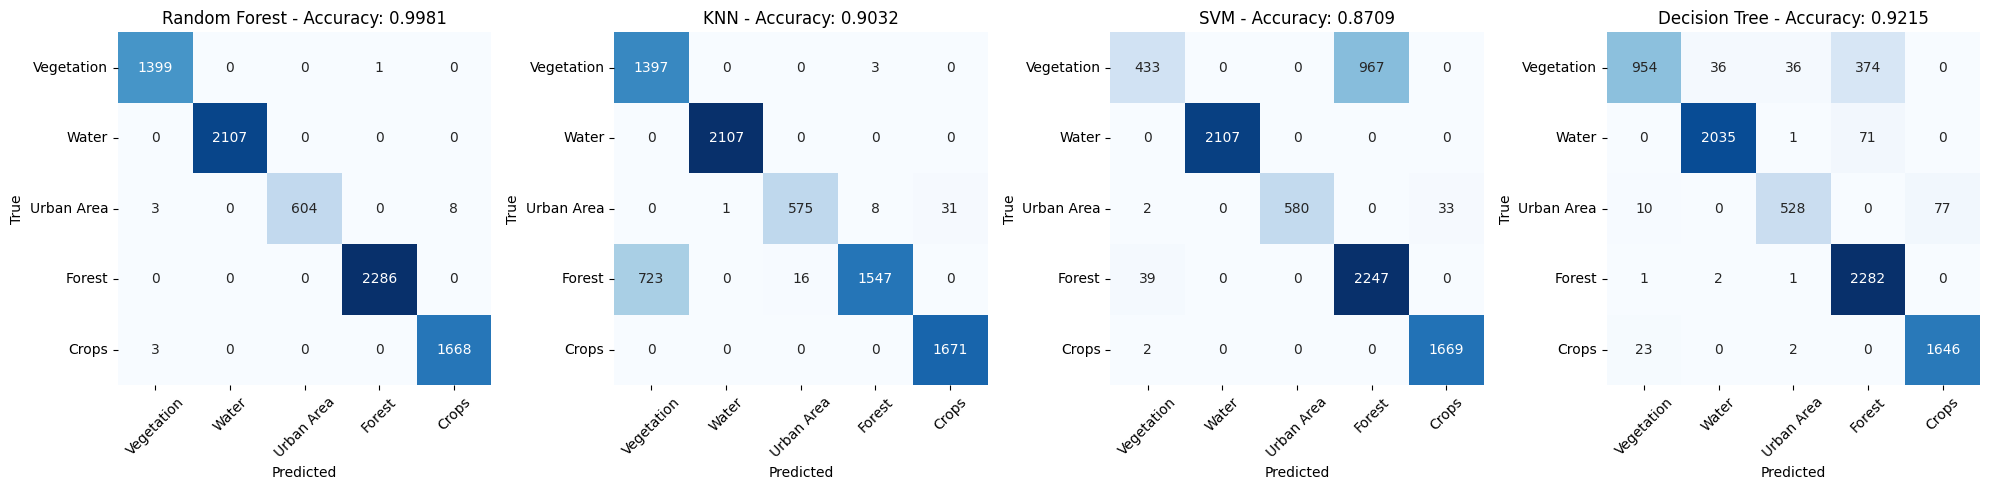

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assurez-vous que seaborn est installé, sinon utilisez : pip install seaborn

# Fonction pour valider un classificateur, calculer la matrice de confusion et l'exactitude
def validate_classifier(classifier, classifier_name, validation_data):
    # Prédictions sur l'ensemble de validation
    validated = validation_data.classify(classifier)

    # Calculer la matrice de confusion
    confusion_matrix = validated.errorMatrix('class', 'classification')

    # Calculer l'exactitude globale
    accuracy = confusion_matrix.accuracy()

    # Convertir la matrice de confusion en tableau numpy
    confusion_array = np.array(confusion_matrix.getInfo())

    # Afficher la matrice de confusion et l'exactitude
    print(f'{classifier_name} - Confusion Matrix:\n', confusion_array)
    print(f'{classifier_name} - Accuracy: {accuracy.getInfo()}')

    return confusion_array, accuracy.getInfo()

# Liste pour stocker les résultats
results = []

# Validation des différents modèles
classifiers = [
    (classifier_rf, 'Random Forest'),
    (knn_classifier, 'KNN'),
    (svm_classifier, 'SVM'),
    (decision_tree_classifier, 'Decision Tree')
]

# Boucle sur les classificateurs pour obtenir et afficher les matrices de confusion
for classifier, name in classifiers:
    confusion, accuracy = validate_classifier(classifier, name, validation)
    results.append((name, confusion, accuracy))

# Fonction pour tracer la matrice de confusion
def plot_confusion_matrices(results):
    num_classifiers = len(results)
    fig, axes = plt.subplots(1, num_classifiers, figsize=(num_classifiers * 5, 5))

    # Classes à étiqueter
    class_labels = ['Vegetation', 'Water', 'Urban Area', 'Forest', 'Crops']

    for ax, (name, confusion, accuracy) in zip(axes, results):
        sns.heatmap(confusion, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=False)
        ax.set_title(f'{name} - Accuracy: {accuracy:.4f}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_xticklabels(class_labels, rotation=45)
        ax.set_yticklabels(class_labels, rotation=0)

    plt.tight_layout()
    plt.show()

# Appel de la fonction pour afficher les matrices de confusion
plot_confusion_matrices(results)


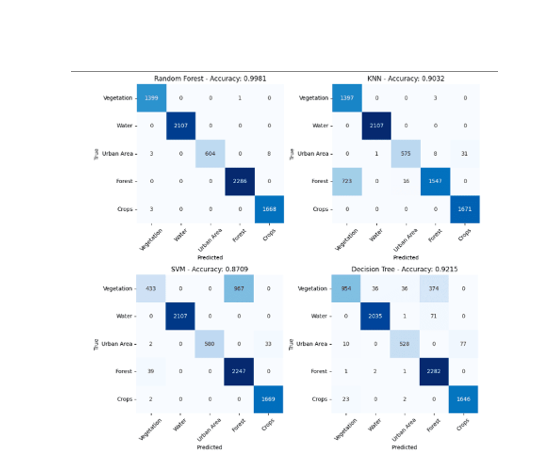

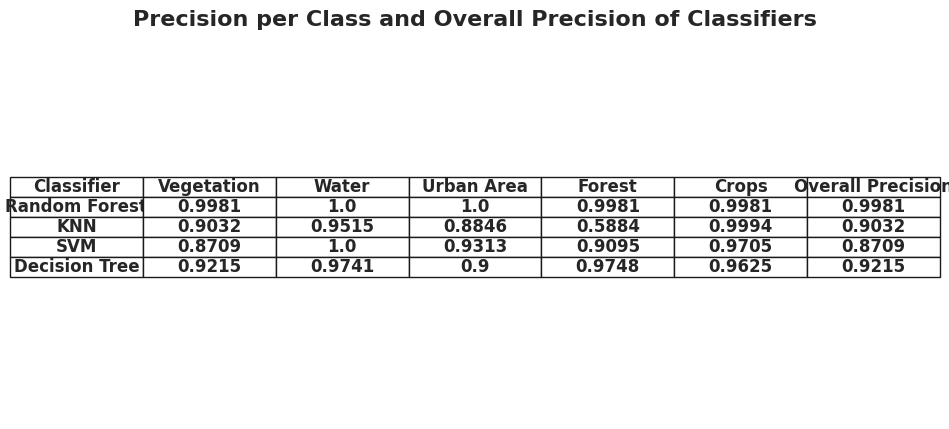

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Données d'exemple des précisions pour chaque classe
data = {
    'Classifier': ['Random Forest', 'KNN', 'SVM', 'Decision Tree'],
    'Vegetation': [0.9981, 0.9032, 0.8709, 0.9215],
    'Water': [1.0000, 0.9515, 1.0000, 0.9741],
    'Urban Area': [1.0000, 0.8846, 0.9313, 0.9000],
    'Forest': [0.9981, 0.5884, 0.9095, 0.9748],
    'Crops': [0.9981, 0.9994, 0.9705, 0.9625],
    'Overall Precision': [0.9981, 0.9032, 0.8709, 0.9215]  # Remplacez par les précisions totales réelles
}

# Créer un DataFrame
df = pd.DataFrame(data)

# Créer un tableau de styles
fig, ax = plt.subplots(figsize=(10, 5))  # Ajustez la taille selon vos besoins
ax.axis('tight')
ax.axis('off')

# Créer un tableau à partir du DataFrame
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Personnalisation du tableau
table.auto_set_font_size(False)
table.set_fontsize(12)  # Taille de la police
table.scale(1.2, 1.2)  # Ajustez la taille du tableau

# Mettre les cellules en gras et changer la police
for (i, j), cell in table.get_celld().items():
    if i == 0:  # En-tête
        cell.set_text_props(fontsize=12, fontweight='bold', fontname='sans-serif')
    else:  # Données
        cell.set_text_props(fontsize=12, fontweight='bold', fontname='sans-serif')

# Ajouter un titre
plt.title('Precision per Class and Overall Precision of Classifiers', fontsize=16, fontweight='bold')

# Afficher le tableau
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Matrices de confusion pour chaque classificateur
confusion_matrices = {
    'Random Forest': np.array([[1399, 0, 0, 1, 0],
                                [0, 2107, 0, 0, 0],
                                [3, 0, 604, 0, 8],
                                [0, 0, 0, 2286, 0],
                                [3, 0, 0, 0, 1668]]),
    'KNN': np.array([[1397, 0, 0, 3, 0],
                     [0, 2107, 0, 0, 0],
                     [0, 1, 575, 8, 31],
                     [723, 0, 16, 1547, 0],
                     [0, 0, 0, 0, 1671]]),
    'SVM': np.array([[433, 0, 0, 967, 0],
                     [0, 2107, 0, 0, 0],
                     [2, 0, 580, 0, 33],
                     [39, 0, 0, 2247, 0],
                     [2, 0, 0, 0, 1669]]),
    'Decision Tree': np.array([[954, 36, 36, 374, 0],
                                [0, 2035, 1, 71, 0],
                                [10, 0, 528, 0, 77],
                                [1, 2, 1, 2282, 0],
                                [23, 0, 2, 0, 1646]])
}

# Noms des classes
classes = ['Vegetation', 'Water', 'Urban Area', 'Forest', 'Crops']

# Liste pour stocker les résultats
results = []

# Calculer les précisions pour chaque classificateur
for classifier_name, confusion in confusion_matrices.items():
    precision_per_class = []
    for i in range(len(classes)):
        TP = confusion[i, i]  # Vrais positifs
        FP = confusion[:, i].sum() - TP  # Faux positifs
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        precision_per_class.append(precision)

    # Calculer la précision totale
    total_TP = confusion.diagonal().sum()
    total_FP = confusion.sum() - total_TP
    overall_precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0

    results.append((classifier_name, precision_per_class, overall_precision))

# Créer un DataFrame avec les résultats
precision_data = {
    'Classifier': [],
    'Vegetation': [],
    'Water': [],
    'Urban Area': [],
    'Forest': [],
    'Crops': [],
    'Overall Precision': []
}

for classifier_name, precision_per_class, overall_precision in results:
    precision_data['Classifier'].append(classifier_name)
    precision_data['Vegetation'].append(precision_per_class[0])
    precision_data['Water'].append(precision_per_class[1])
    precision_data['Urban Area'].append(precision_per_class[2])
    precision_data['Forest'].append(precision_per_class[3])
    precision_data['Crops'].append(precision_per_class[4])
    precision_data['Overall Precision'].append(overall_precision)

# Convertir en DataFrame
precision_df = pd.DataFrame(precision_data)

# Formatage pour l'affichage
precision_df = precision_df.round(5)  # Arrondir à 4 décimales
precision_df.set_index('Classifier', inplace=True)

# Afficher le tableau
print(precision_df)


               Vegetation    Water  Urban Area   Forest    Crops  \
Classifier                                                         
Random Forest     0.99573  1.00000     1.00000  0.99956  0.99523   
KNN               0.65896  0.99953     0.97293  0.99294  0.98179   
SVM               0.90966  1.00000     1.00000  0.69913  0.98061   
Decision Tree     0.96559  0.98167     0.92958  0.83682  0.95531   

               Overall Precision  
Classifier                        
Random Forest            0.99814  
KNN                      0.90321  
SVM                      0.87090  
Decision Tree            0.92152  


Based on my study and extensive research on land cover classification, Random Forest (RF) and K-Nearest Neighbors (KNN) emerged as the best-performing models. However, I’ve kept the implementation flexible, allowing you to select the classifier that best suits your specific region and the number of classes in your dataset.

The following code enables you to save and apply your chosen model, facilitating temporal analysis to extract statistics and monitor the monthly evolution of land cover changes in your area. This approach ensures adaptability and relevance for diverse use cases.

# 6.CNNs Testing and Validation


We try to build a NN to see if it can pefrom better but we have to format the input for the Nn

In [ ]:
export_task = ee.batch.Export.table.toDrive(
    collection=training_data,
    description='TrainingDataExport',
    fileFormat='CSV',
    folder='Data_Fusion_Training_Set'  # Specify the Google Drive folder
)
export_task.start()


In [18]:
import pandas as pd

# Load the CSV file
file_path = '/content/drive/MyDrive/Data_Fusion_Training_Set/TrainingDataExport.csv'
df = pd.read_csv(file_path)

# Extract the feature columns and the class labels
X_train = df[['VV', 'VH', 'VH_VV', 'VV_1', 'VH_1', 'VH_VV_1', 'VV_2', 'VH_2', 'VH_VV_2', 'VV_3', 'VH_3', 'VH_VV_3', 'B2', 'B3', 'B4', 'B8', 'NDVI', 'SAVI', 'BAI', 'NDWI']].values
y_train = df['class'].values


In [19]:
print(X_train.shape)
print(y_train.shape)

(3605, 20)
(3605,)


In [ ]:
import numpy as np
import tensorflow as tf

# Convert to TensorFlow tensors
X_train = np.array(X_train)
y_train = np.array(y_train)

# Define and compile the neural network
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')  # Adjust for number of classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7635 - loss: 45.1158
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9207 - loss: 0.8559
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9327 - loss: 0.6599
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9424 - loss: 0.7032
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9501 - loss: 0.5095
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9229 - loss: 1.1020
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9502 - loss: 0.5426
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9286 - loss: 1.1161
Epoch 9/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9668 - loss: 0.3117
Epoch 10/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9635 - loss: 0.4959


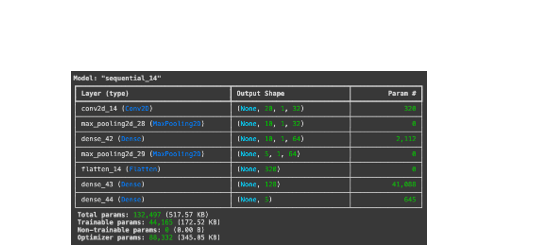

In [ ]:
import time

# Créer une FeatureCollection à partir de l'image fusionnée
def create_feature_collection(image):
    # Échantillonner l'image sur une grille de points (ou un polygone)
    points = image.sample(
        region=polygon,  # Définissez la région d'intérêt
        scale=10,  # Résolution selon vos données
        numPixels=100  # Nombre de points à échantillonner
    )
    # Ajouter les coordonnées
    points = points.map(lambda f: f.set('longitude', f.geometry().coordinates().get(0))
                                     .set('latitude', f.geometry().coordinates().get(1)))
    return points

# Créer la FeatureCollection à partir de l'image fusionnée
feature_collection = create_feature_collection(merged_image)

# Exporter la FeatureCollection en tant que fichier CSV
export_task = ee.batch.Export.table.toDrive(
    collection=feature_collection,
    description='IndependentImageExport',
    fileFormat='CSV',
    folder='Data_Fusion_Training_Set'  # Dossier dans Google Drive
)

export_task.start()

# Surveillance de l'état de la tâche d'exportation
print("Export task started. Monitoring status...")

# Vérifiez le statut de la tâche d'exportation
while export_task.active():
    status = export_task.status()
    print("Export status:", status['state'])
    time.sleep(30)

final_status = export_task.status()
if final_status['state'] == 'COMPLETED':
    print("Export task completed successfully! Check your Google Drive for the CSV file.")
else:
    print("Export task failed. Please check the logs for more details.")


Export task started. Monitoring status...
Export status: READY
Export status: RUNNING
Export task failed. Please check the logs for more details.


In [ ]:
import pandas as pd
import numpy as np

# Load the merged image data from CSV
merged_image_data = pd.read_csv('/content/drive/MyDrive/Data_Fusion_Training_Set/IndependentImageExport.csv')

print("Colonnes disponibles dans le CSV :", merged_image_data.columns)

# Extract feature columns from the image data (ensure these feature names match your CSV)
X_image = merged_image_data[['VV', 'VH', 'VH_VV', 'VV_1', 'VH_1', 'VH_VV_1',
                             'VV_2', 'VH_2', 'VH_VV_2', 'VV_3', 'VH_3', 'VH_VV_3',
                             'B2', 'B3', 'B4', 'B8', 'NDVI', 'SAVI', 'BAI', 'NDWI']].values

# Ensure the model is trained and ready for prediction
if model is not None:
    # Make predictions on the features
    y_pred = model.predict(X_image)

    # If your model's output is one-hot encoded, use np.argmax to get the class index
    predicted_classes = np.argmax(y_pred, axis=1)

    # Add the predicted class column to the dataframe
    merged_image_data['predicted_class'] = predicted_classes

    # Save the predicted data to a new CSV file
    merged_image_data.to_csv('/content/drive/MyDrive/Data_Fusion_Training_Set/ClassifiedImage.csv', index=False)

    print("Prediction completed and saved to ClassifiedImage.csv")
else:
    print("Error: The model is not defined or trained.")


Colonnes disponibles dans le CSV : Index(['system:index', 'B2', 'B3', 'B4', 'B8', 'BAI', 'NDVI', 'NDWI', 'SAVI',
       'VH', 'VH_1', 'VH_2', 'VH_3', 'VH_VV', 'VH_VV_1', 'VH_VV_2', 'VH_VV_3',
       'VV', 'VV_1', 'VV_2', 'VV_3', '.geo'],
      dtype='object')
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Prediction completed and saved to ClassifiedImage.csv


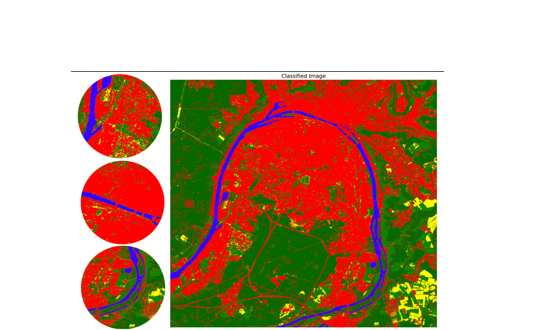


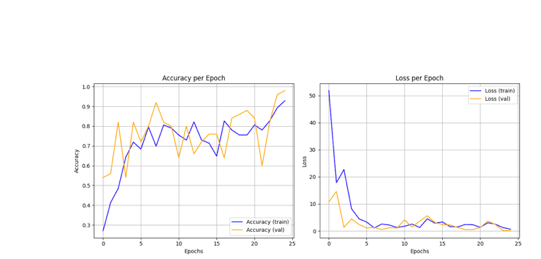

CNN validation other appraoach test

In [ ]:
import geemap

"""
Fonction pour afficher les indices Sentinel-2 et les images Sentinel-1 et Sentinel-2 en RGB.

Paramètres :
- s1_image : Image Sentinel-1 prétraitée
- s2_image : Image Sentinel-2 prétraitée avec bandes et indices
- geometry : Zone d'intérêt à afficher
"""
# Créer une carte interactive
Map = geemap.Map()

# Centrer la carte sur le polygone (geometry) avec un facteur de zoom automatique
Map.centerObject(polygon, zoom=10)

# Afficher l'image Sentinel-2 en RGB
s2_rgb_viz = {
    'min': 0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2']  # Rouge, Vert, Bleu
}
Map.addLayer(s2_image.clip(polygon), s2_rgb_viz, 'Sentinel-2 (RGB)')

# Afficher la carte
Map.addLayerControl()  # Ajouter un contrôle pour les couches

# Activer le mode dessin pour ajouter des échantillons directement sur la carte
Map.add_draw_control()

# Afficher la carte
Map


Map(center=[49.393998839918474, 1.071313973159288], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
def get_drawn_points():
    # Récupérer les features dessinées sur la carte
    drawn_features = Map.draw_features  # Utiliser la propriété pour obtenir les features
    points = []
    # Boucle sur chaque feature dessinée
    for feature in drawn_features:
        coords = feature.geometry().coordinates().getInfo()  # Récupérer les coordonnées du point
        # Ajouter le point avec la classe correspondante (à définir selon l'ordre où tu as dessiné les points)
        class_value = len(points)  # Classe de 0 à 4
        points.append({'coords': coords, 'class_value': class_value})
    return points

points = get_drawn_points()

In [ ]:
import geemap
import pandas as pd
import ee

# Load the classified image data from CSV
classified_data = pd.read_csv('/content/drive/MyDrive/Data_Fusion_Training_Set/ClassifiedImage.csv')


# Afficher les noms des colonnes
print(classified_data.columns)
# Convert the DataFrame to a FeatureCollection
features = []
for index, row in classified_data.iterrows():
    point = ee.Geometry.Point([row['longitude'], row['latitude']])  # Replace with your longitude and latitude columns
    feature = ee.Feature(point, {'predicted_class': int(row['predicted_class'])})
    features.append(feature)

# Create an Earth Engine FeatureCollection
fc = ee.FeatureCollection(features)

# Create a map using Geemap
Map = geemap.Map()
Map.centerObject(fc, zoom=10)

# Add the classified points to the map with a color palette
palette = ['red', 'green', 'blue', 'yellow', 'purple']  # Adjust this palette based on your classes
Map.addLayer(fc.style(color='predicted_class', palette=palette), {}, 'Classified Image')

# Display the map
Map.add_child(geemap.LayerControl())
Map


Index(['system:index', 'B2', 'B3', 'B4', 'B8', 'BAI', 'NDVI', 'NDWI', 'SAVI',
       'VH', 'VH_1', 'VH_2', 'VH_3', 'VH_VV', 'VH_VV_1', 'VH_VV_2', 'VH_VV_3',
       'VV', 'VV_1', 'VV_2', 'VV_3', '.geo', 'predicted_class'],
      dtype='object')


KeyError: 'longitude'

# 7. AUTOMATION AND DATA ANALYSIS ( Work in progress )

Now that we have a well-trained model, the next step is to automate the process to generate land use classification for a specific date through a single function. This will allow us to retrieve land cover maps for any given date efficiently.

In the future, the workflow can be extended to automate the analysis over a chosen temporal window, enabling comprehensive data analysis on temporal land cover changes. For example, this could include tracking the evolution of urban areas, forests, water bodies, or performing basic statistical evaluations of these changes over time.

***However, this feature is currently a work in progress. Due to time constraints, I haven’t been able to finalize this aspect yet, but it remains a priority for future development.***








In [ ]:
import ee

# Initialisation de l'API Earth Engine
ee.Initialize()

# Charger la collection Sentinel-1
s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(polygon) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
    .select(['VV', 'VH'])

def get_s1_images(date):
    # Extraire l'année et le mois à partir de la date
    date_obj = ee.Date(date)
    year = int(date_obj.get('year').getInfo())
    month = int(date_obj.get('month').getInfo())

    # Définir les périodes hebdomadaires du mois spécifié
    periods = [
        ('{}-{:02d}-01'.format(year, month), '{}-{:02d}-07'.format(year, month)),
        ('{}-{:02d}-08'.format(year, month), '{}-{:02d}-14'.format(year, month)),
        ('{}-{:02d}-15'.format(year, month), '{}-{:02d}-21'.format(year, month)),
        ('{}-{:02d}-22'.format(year, month), '{}-{:02d}-28'.format(year, month))
    ]

    # Ajouter les jours de fin de mois si nécessaire
    end_day = ee.Date('{}-{:02d}-01'.format(year, month)).advance(1, 'month').advance(-1, 'day').get('day').getInfo()
    last_period_end = '{}-{:02d}-{}'.format(year, month, end_day)
    periods[-1] = (periods[-1][0], last_period_end)  # Mettre à jour le dernier intervalle

    images = []
    for start_date, end_date in periods:
        print(f"Processing period: {start_date} to {end_date}")
        s1_period = s1_collection.filterDate(start_date, end_date)

        print(f"Number of images: {s1_period.size().getInfo()}")
        if s1_period.size().getInfo() > 0:  # Vérifier qu'il y a des images pour la période
            s1_mean = s1_period.mean().clip(polygon)

            # Calculer les bandes dérivées
            ratio_vv_vh = s1_mean.expression(
                'VV - VH', {
                    'VV': s1_mean.select('VV'),
                    'VH': s1_mean.select('VH')
                }).rename('VV_VH')

            # Ajouter les bandes VV, VH, et les bandes dérivées
            s1_image = s1_mean.addBands([ratio_vv_vh])

            images.append(s1_image)
            print(f"Added image for period: {start_date} to {end_date}")

    print(f"Total number of images collected: {len(images)}")
    # Assurer que nous avons exactement 4 images, sinon ajuster en fonction de la disponibilité
    return images[:4]  # Prendre les 4 premières images disponibles

# Exemple d'appel de la fonction
s1_images = get_s1_images('2023-06-15')

# Fusionner les 4 images Sentinel-1 en une seule
def merge_s1_images(s1_images):
    if not s1_images:
        return None
    merged_s1 = s1_images[0]
    for img in s1_images[1:]:
        merged_s1 = merged_s1.addBands(img)
    return merged_s1

merged_s1_image = merge_s1_images(s1_images)

# Afficher les informations pour le débogage
if merged_s1_image:
    print(f"Band names in merged image: {merged_s1_image.bandNames().getInfo()}")
else:
    print("No images available for merging.")


Processing period: 2023-06-01 to 2023-06-07
Number of images: 0
Processing period: 2023-06-08 to 2023-06-14
Number of images: 1
Added image for period: 2023-06-08 to 2023-06-14
Processing period: 2023-06-15 to 2023-06-21
Number of images: 0
Processing period: 2023-06-22 to 2023-06-30
Number of images: 0
Total number of images collected: 1
Band names in merged image: ['VV', 'VH', 'VV_VH']


In [ ]:
import ee

# Initialisation de l'API Earth Engine
ee.Initialize()

# Charger la collection Sentinel-1
s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(polygon) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
    .select(['VV', 'VH'])

def get_s1_images(year):
    # Définir les périodes mensuelles pour l'année spécifiée
    periods = [
        ('{}-01-01'.format(year), '{}-01-31'.format(year)),
        ('{}-02-01'.format(year), '{}-02-28'.format(year)),
        ('{}-03-01'.format(year), '{}-03-31'.format(year)),
        ('{}-04-01'.format(year), '{}-04-30'.format(year)),
        ('{}-05-01'.format(year), '{}-05-31'.format(year)),
        ('{}-06-01'.format(year), '{}-06-30'.format(year)),
        ('{}-07-01'.format(year), '{}-07-31'.format(year)),
        ('{}-08-01'.format(year), '{}-08-31'.format(year)),
        ('{}-09-01'.format(year), '{}-09-30'.format(year)),
        ('{}-10-01'.format(year), '{}-10-31'.format(year)),
        ('{}-11-01'.format(year), '{}-11-30'.format(year)),
        ('{}-12-01'.format(year), '{}-12-31'.format(year))
    ]

    images = []
    for start_date, end_date in periods:
        print(f"Processing period: {start_date} to {end_date}")
        s1_period = s1_collection.filterDate(start_date, end_date)

        print(f"Number of images: {s1_period.size().getInfo()}")
        if s1_period.size().getInfo() > 0:  # Vérifier qu'il y a des images pour la période
            s1_mean = s1_period.mean().clip(polygon)

            # Calculer les bandes dérivées
            ratio_vv_vh = s1_mean.expression(
                'VV - VH', {
                    'VV': s1_mean.select('VV'),
                    'VH': s1_mean.select('VH')
                }).rename('VV_VH')

            # Ajouter les bandes VV, VH, et les bandes dérivées
            s1_image = s1_mean.addBands([ratio_vv_vh])

            images.append(s1_image)
            print(f"Added image for period: {start_date} to {end_date}")

    print(f"Total number of images collected: {len(images)}")
    # Assurer que nous avons exactement 12 images, sinon ajuster en fonction de la disponibilité
    return images[:12]  # Prendre les 12 premières images disponibles (une pour chaque mois)

# Exemple d'appel de la fonction pour l'année 2023
s1_images = get_s1_images(2023)

# Fusionner les images Sentinel-1 en une seule
def merge_s1_images(s1_images):
    if not s1_images:
        return None
    merged_s1 = s1_images[0]
    for img in s1_images[1:]:
        merged_s1 = merged_s1.addBands(img)
    return merged_s1

merged_s1_image = merge_s1_images(s1_images)

# Afficher les informations pour le débogage
if merged_s1_image:
    print(f"Band names in merged image: {merged_s1_image.bandNames().getInfo()}")
else:
    print("No images available for merging.")


Processing period: 2023-01-01 to 2023-01-31
Number of images: 3
Added image for period: 2023-01-01 to 2023-01-31
Processing period: 2023-02-01 to 2023-02-28
Number of images: 2
Added image for period: 2023-02-01 to 2023-02-28
Processing period: 2023-03-01 to 2023-03-31
Number of images: 3
Added image for period: 2023-03-01 to 2023-03-31
Processing period: 2023-04-01 to 2023-04-30
Number of images: 2
Added image for period: 2023-04-01 to 2023-04-30
Processing period: 2023-05-01 to 2023-05-31
Number of images: 3
Added image for period: 2023-05-01 to 2023-05-31
Processing period: 2023-06-01 to 2023-06-30
Number of images: 2
Added image for period: 2023-06-01 to 2023-06-30
Processing period: 2023-07-01 to 2023-07-31
Number of images: 3
Added image for period: 2023-07-01 to 2023-07-31
Processing period: 2023-08-01 to 2023-08-31
Number of images: 2
Added image for period: 2023-08-01 to 2023-08-31
Processing period: 2023-09-01 to 2023-09-30
Number of images: 3
Added image for period: 2023-09-

We realise now that we need to work with a longer timestamp , maybe trimestraial analysis

In [ ]:
import ee

# Initialisation de l'API Earth Engine
ee.Initialize()

def classify_land_use(date, polygon, training_samples, classifier):
    # Fonction de masquage des nuages pour Sentinel-2
    def maskS2clouds(image):
        qa = image.select('QA60')
        cloudBitMask = 1 << 10
        cirrusBitMask = 1 << 11
        mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
                 .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
        return image.updateMask(mask).copyProperties(image, ["system:time_start"])

    # Charger la collection Sentinel-2 avec un seuil de couverture nuageuse plus large
    s2_collection = ee.ImageCollection('COPERNICUS/S2_SR') \
        .filterBounds(polygon) \
        .filterDate(date, ee.Date(date).advance(1, 'month').format('YYYY-MM-dd')) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 100)) \
        .map(maskS2clouds)

    # Sélectionner l'image avec la couverture nuageuse minimale disponible
    def select_best_image(collection):
        # Trier les images par couverture nuageuse croissante
        sorted_images = collection.sort('CLOUDY_PIXEL_PERCENTAGE')
        best_image = ee.Image(sorted_images.first())
        return best_image

    # Remplacer cette partie :
    # s2_best_image = select_best_image(s2_collection)

    # Par la mosaïque Sentinel-2 pour couvrir tout le polygone
    def mosaic_s2_images(collection, polygon):
        # Créer une mosaïque des images Sentinel-2 disponibles et la clipper au polygone
        mosaic = collection.mosaic().clip(polygon)
        return mosaic

    # Créer la mosaïque des images Sentinel-2 et appliquer les indices
    s2_mosaic_image = mosaic_s2_images(s2_collection, polygon)
    #s2_image = addIndices(s2_mosaic_image.select(s2_bands))

    # Ajouter les indices à l'image Sentinel-2
    def addIndices(image):
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
        savi = image.expression(
            '1.5 * (NIR - RED) / (NIR + RED + 0.5)', {
                'NIR': image.select('B8'),
                'RED': image.select('B4')
            }).rename('SAVI')
        bai = image.expression(
            '(BLUE - NIR) / (BLUE + NIR)', {
                'BLUE': image.select('B2'),
                'NIR': image.select('B8')
            }).rename('BAI')
        ndwi = image.normalizedDifference(['B8', 'B4']).rename('NDWI')
        return image.addBands([ndvi, savi, bai, ndwi])

    s2_bands = ['B2', 'B4', 'B8', 'B3']
    #print(s2_best_image.bandNames().getInfo())
   # s2_image = addIndices(s2_best_image.select(s2_bands)).clip(polygon)
    s2_image = addIndices(s2_mosaic_image.select(s2_bands))


    # Charger la collection Sentinel-1
    s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterBounds(polygon) \
        .filter(ee.Filter.eq('instrumentMode', 'IW')) \
        .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
        .select(['VV', 'VH'])


    def get_s1_images(date):
      # Extraire l'année et le mois à partir de la date
      date_obj = ee.Date(date)
      year = int(date_obj.get('year').getInfo())
      month = int(date_obj.get('month').getInfo())

      # Définir les mois précédents et le mois actuel
      previous_months = [month - 1, month - 2,month - 3]
      current_month = month

      # Assurer que les mois précédents sont valides (entre 1 et 12)
      valid_months = [m for m in previous_months if 1 <= m <= 12]
      valid_months.append(current_month)

      images = []
      for m in valid_months:
          start_date = '{}-{:02d}-01'.format(year, m)
          end_date = ee.Date(start_date).advance(1, 'month').advance(-1, 'day').format('YYYY-MM-dd').getInfo()

          s1_period = s1_collection.filterDate(start_date, end_date)
          if s1_period.size().getInfo() > 0:  # Vérifier qu'il y a des images pour la période
              s1_mean = s1_period.mean().clip(polygon)

              # Calculer les bandes dérivées
              ratio_vv_vh = s1_mean.expression(
                  'VV - VH', {
                      'VV': s1_mean.select('VV'),
                      'VH': s1_mean.select('VH')
                  }).rename('VH_VV')

              # Ajouter les bandes VV, VH, et les bandes dérivées
              s1_image = s1_mean.addBands([ratio_vv_vh])

              images.append(s1_image)
              print(s1_image.bandNames().getInfo())

      # Assurer que nous avons exactement 4 images, sinon ajuster en fonction de la disponibilité
      return images[:4]  # Prendre les 4 premières images disponibles


    def merge_s1_images(s1_images):
        merged_s1 = s1_images[0]
        for img in s1_images[1:]:
            merged_s1 = merged_s1.addBands(img)
        return merged_s1

    # Récupérer les images Sentinel-1 et les fusionner
    s1_images = get_s1_images(date)
    merged_s1_image = merge_s1_images(s1_images)
    print(merged_s1_image.bandNames().getInfo())

    # Fusionner Sentinel-1 et Sentinel-2
    merged_image = merged_s1_image.addBands(s2_image)
    print(merged_image.bandNames().getInfo())

    # Ajouter les échantillons de formation à l'image fusionnée
    training = merged_image.sampleRegions(
        collection=training_samples,
        properties=['class'],
        scale=10
    )

    # Classifier l'image fusionnée avec le modèle pré-entraîné
    classified_image = merged_image.classify(classifier)

    return classified_image



# Définir le classificateur pré-entraîné (remplacer par votre modèle)
pretrained_classifier = knn_classifier  # Remplacer par votre classificateur pré-entraîné

# Appeler la fonction pour une date spécifique
classified_image = classify_land_use('2023-08-15', polygon, training_samples_drive, pretrained_classifier)

# Affichage avec geemap
Map = geemap.Map()
Map.addLayer(classified_image, {'min': 0, 'max': 4, 'palette': ['green', 'blue', 'red', '#004d00', 'yellow']}, 'Classified Image')
Map.centerObject(polygon, 10)
Map.addLayer(polygon, {}, 'Polygon')
Map.addLayer(training_samples_drive, {}, 'Training Samples')
Map


# Exemple d'utilisation
#SAVE LE TRAINING SAMPLE
#SAVE LE MODEL ENTRAINE




['VV', 'VH', 'VH_VV']
['VV', 'VH', 'VH_VV']
['VV', 'VH', 'VH_VV']
['VV', 'VH', 'VH_VV']
['VV', 'VH', 'VH_VV', 'VV_1', 'VH_1', 'VH_VV_1', 'VV_2', 'VH_2', 'VH_VV_2', 'VV_3', 'VH_3', 'VH_VV_3']
['VV', 'VH', 'VH_VV', 'VV_1', 'VH_1', 'VH_VV_1', 'VV_2', 'VH_2', 'VH_VV_2', 'VV_3', 'VH_3', 'VH_VV_3', 'B2', 'B4', 'B8', 'B3', 'NDVI', 'SAVI', 'BAI', 'NDWI']


Map(center=[49.393998839918474, 1.071313973159288], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# Appeler la fonction pour une date spécifique
classified_image = classify_land_use('2023-06-15', polygon, training_samples, pretrained_classifier)

# Affichage avec geemap
Map = geemap.Map()
Map.addLayer(classified_image, {'min': 0, 'max': 4, 'palette': ['green', 'blue', 'red', '#004d00', 'yellow']}, 'Classified Image')
Map.centerObject(polygon, 10)
Map.addLayer(polygon, {}, 'Polygon')
Map.addLayer(training_samples, {}, 'Training Samples')
Map

EEException: Image.classify: The image to be classified does not contain all the bands which the classifier expects.
  Image bands: [VV, VH, VH_VV].
  Classifier inputs: [VV, VH, VH_VV, VV_1, VH_1, VH_VV_1, VV_2, VH_2, VH_VV_2, VV_3, VH_3, VH_VV_3, B2, B3, B4, B8, NDVI, SAVI, BAI, NDWI].
  Missing bands: [SAVI, VH_VV_1, BAI, VH_1, NDWI, VH_2, NDVI, VH_3, B2, B3, B4, VH_VV_3, B8, VH_VV_2, VV_1, VV_2, VV_3].